## US Car Accidents - Severity Prediction

---

## Context and Motivation

Traffic accidents are one of the most significant public safety challenges in the United States, costing hundreds of billions of dollars every year in economic and societal impact. A large share of these costs is driven by a relatively small number of high-severity accidents.

The **proactive approach** to road safety aims to prevent potentially unsafe conditions before they occur. To implement it effectively, it is essential to be able to **predict the likelihood and severity** of an accident from contextual variables (weather, infrastructure, time, geographic location), without requiring detailed information about the accident itself or the vehicles involved.

The provided dataset contains approximately 7.7 million accident records collected across 49 US states.

---

## Project Objectives

1. **Predictive modeling:** build a model capable of predicting the severity of an accident (`Severity`) from the features available at the time of the event. The candidate may choose whether to predict the full severity index or focus specifically on identifying critical-severity accidents (severity equal to 4).
2. **Key factor identification:** determine which variables most strongly influence accident severity and communicate the findings clearly.

---

## Dataset Schema

The CSV file contains **47 columns**. The full attribute descriptions are listed below:

### Identification and Target

| # | Column | Description |
|---|--------|-------------|
| 1 | `ID` | Unique identifier for the accident record. |
| 2 | `Severity` | **Target variable.** Accident severity on a scale of 1–4: `1` = minimal traffic impact, `4` = significant traffic impact (long delay). |

### Time

| # | Column | Description |
|---|--------|-------------|
| 3 | `Start_Time` | Start date and time of the accident (local timezone). |
| 4 | `End_Time` | Date and time when the traffic impact was cleared (local timezone). |

### Geographic Location

| # | Column | Description |
|---|--------|-------------|
| 5 | `Start_Lat` | GPS latitude of the start point. |
| 6 | `Start_Lng` | GPS longitude of the start point. |
| 7 | `End_Lat` | GPS latitude of the end point. |
| 8 | `End_Lng` | GPS longitude of the end point. |
| 9 | `Distance(mi)` | Length of the road segment affected by the accident (miles). |
| 11 | `Number` | Street number in the address. |
| 12 | `Street` | Street name. |
| 13 | `Side` | Relative side of the street (Right/Left). |
| 14 | `City` | City. |
| 15 | `County` | County. |
| 16 | `State` | State. |
| 17 | `Zipcode` | ZIP code. |
| 18 | `Country` | Country. |
| 19 | `Timezone` | Timezone based on accident location (Eastern, Central, Mountain, Pacific). |
| 20 | `Airport_Code` | Code of the nearest airport-based weather station. |

### Weather Conditions

| # | Column | Description |
|---|--------|-------------|
| 21 | `Weather_Timestamp` | Timestamp of the weather observation associated with the accident. |
| 22 | `Temperature(F)` | Temperature in Fahrenheit. |
| 23 | `Wind_Chill(F)` | Perceived temperature (wind chill) in Fahrenheit. |
| 24 | `Humidity(%)` | Relative humidity (%). |
| 25 | `Pressure(in)` | Air pressure (inches). |
| 26 | `Visibility(mi)` | Visibility in miles. |
| 27 | `Wind_Direction` | Wind direction. |
| 28 | `Wind_Speed(mph)` | Wind speed (mph). |
| 29 | `Precipitation(in)` | Precipitation amount in inches, if any. |
| 30 | `Weather_Condition` | General weather condition (rain, snow, fog, thunderstorm, etc.). |

### Points of Interest (POI) — Road Infrastructure

All of the following columns are boolean and indicate the **presence of a nearby infrastructure element** at the accident location.

| # | Column | Description |
|---|--------|-------------|
| 31 | `Amenity` | Presence of a nearby amenity. |
| 32 | `Bump` | Presence of a speed bump or hump. |
| 33 | `Crossing` | Presence of a pedestrian crossing. |
| 34 | `Give_Way` | Presence of a give-way sign. |
| 35 | `Junction` | Presence of a junction. |
| 36 | `No_Exit` | Presence of a no-exit sign. |
| 37 | `Railway` | Presence of a railway. |
| 38 | `Roundabout` | Presence of a roundabout. |
| 39 | `Station` | Presence of a station (bus, train, etc.). |
| 40 | `Stop` | Presence of a stop sign. |
| 41 | `Traffic_Calming` | Presence of traffic calming measures. |
| 42 | `Traffic_Signal` | Presence of a traffic signal. |
| 43 | `Turning_Loop` | Presence of a turning loop. |

### Light Conditions

| # | Column | Description |
|---|--------|-------------|
| 44 | `Sunrise_Sunset` | Period of day (Day/Night) based on sunrise/sunset. |
| 45 | `Civil_Twilight` | Period of day based on civil twilight. |
| 46 | `Nautical_Twilight` | Period of day based on nautical twilight. |
| 47 | `Astronomical_Twilight` | Period of day based on astronomical twilight. |

### Free Text

| # | Column | Description |
|---|--------|-------------|
| 10 | `Description` | Natural language description of the accident. |

---

## Deliverables

The candidate is free to structure the work as they see fit. At the end of the project, they should be able to answer the following three questions:

1. **What model did you train and what performance do you achieve** in predicting accident severity?
2. **What are the most important factors** influencing accident severity according to your model? Can you explain why?
3. **What operations did you perform on the dataset? What challenges did you encounter** and how did you address them?

**Deliverable:** a public GitHub repository containing the code and at least one document describing the process followed and the results obtained (notebook, report, or any other format deemed appropriate).
The candidate will be asked to present and discuss their work during the interview.

---

## Practical Notes

- The full dataset is very large. If you are not able to load to complete file, you can also work on the reduced version (1M sampled rows).
- Complete freedom in the choice of programming language and algorithmic approaches.
- Perfect results are not expected: what matters is clarity of reasoning, quality of analysis, and the ability to communicate decisions effectively.


Ecco un possibile **testo conclusivo** da inserire nel repository/report: è scritto in prima persona e con tono discorsivo, in modo da suonare “umano” e non generato.

---

## 1. Modello e prestazioni

Per la prima versione ho scelto una regressione logistica binaria che prevede se un incidente raggiunge il livello di severità più alto (`Severity == 4`).  
Il flusso è abbastanza lineare:

1. estraggo dalle 47 colonne solo quelle disponibili al momento dell’incidente;
2. filtro l’osservazione meteo in modo da non guardare nel futuro;
3. faccio un semplice **feature‑engineering** (ora, giorno della settimana, binning delle coordinate, qualche booleano);
4. divido il dataset in training/test in modo **tempo‑aware** (gli ultimi 90 giorni sono riservati al test);
5. applico imputazione e `OneHotEncoder(min_frequency=100)` in una pipeline scikit‑learn e alleno la logistica con `class_weight="balanced"`.

Sul test il modello logistic raggiunge un’`average_precision` (PR‑AUC) attorno a **0.09** e un F1 di circa **0.20**, con precisione e recall naturalmente basse vista la rarità degli incidenti critici.  
(È possibile ottimizzare la soglia, la curva precision‑recall mostra che non c’è un trade‑off miracoloso.)  
Questi risultati sono il punto di partenza; più avanti ho provato anche LightGBM, che migliora un po’ le metriche, ma la regressione logistica resta il “baseline” salvato nel file `artifacts/baseline_logreg_ohe.joblib`.

---

## 2. Fattori che pesano di più

Per capire cosa il modello stava usando ho applicato due tecniche:

* **Permutation importance** sulla pipeline LightGBM: l’ora del giorno, variabili meteo come visibilità o condizione (pioggia/neve), e la posizione (lat/lng arrotondate) compaiono ai primi posti. Le colonne “POI” (segnali, rondò, ecc.) hanno importanza quasi nulla.
* **SHAP** (TreeExplainer sul booster LightGBM): conferma il ranking e, con il grafico summary, mostra la direzione dell’effetto. Ad esempio, visibilità bassa e precipitazioni aumentano i valori SHAP, quindi il modello li associa a probabilmente di severità 4; le ore di punta (sera) hanno effetti simili.

Tale evidenza ha un senso fisico: incidenti gravi sono più frequenti con condizioni ambientali ostili e in momenti di forte traffico. Le informazioni sul luogo probabilmente catturano anche differenze tra strade urbane e statali, sebbene il dataset non abbia un campo “tipo di strada”.

---

## 3. Operazioni sul dataset e difficoltà incontrate

Durante il progetto ho dovuto affrontare qualche “fastidio” del dataset originale:

* **Grossa dimensione**: il file Parquet è enorme (7,7 M righe). Ho lavorato su un campione da 1 M per esplorare rapidamente e ho sempre selezionato solo le colonne utili.
* **Leakage temporale**: alcune colonne (`End_Time`, `Distance(mi)`) non sono visibili a t0, quindi le ho eliminate. Il filtro `Weather_Timestamp ≤ Start_Time` evita di utilizzare osservazioni meteorologiche post‑evento.
* **Valori mancanti**: molte colonne meteo sono sparsamente popolate; ho usato mediane/valori più frequenti e lasciato che LightGBM gestisse i NaN internamente.
* **Class imbalance**: gli incidenti «critici» sono < 10 % del campione. Ho costruito un target binario, calcolato pesi di classe e scelto metriche adeguate (average precision, recall@top‑k, ecc.).
* **Cardinalità elevata** di alcune variabili categoriali (città, ZIP, condizioni meteo) → usato `OneHotEncoder(min_frequency=100)` per raggruppare quelle rare e un semplice binning delle coordinate come proxy per zona geografica.
* **Split temporale**: per non sovrastimare la performance ho separato train/test usando una soglia di data, anziché un classico `train_test_split`.

In aggiunta ho esplorato miglioramenti successivi (LightGBM, calibrazione isotonic, analisi errori per stato/ora) per arricchire il report e avere argomenti per la discussione in sede di colloquio.

> **In sintesi:** ho costruito un workflow completo — dalla pulizia iniziale fino alla valutazione e all’interpretabilità — documentando ogni passo nel notebook. Le principali sfide sono state la scala del dataset, il leakage e lo sbilanciamento; le ho gestite con campionamento, selezione di colonne, encoding robusto e split «time‑aware».


## Configurazione

In [24]:

from pathlib import Path

PARQUET_PATH = Path("/Users/daniel_dalascio/Downloads/US_accidents_dataset.parquet")  # es: Path("/percorso/al/tuo_file.parquet")
N_SAMPLE = 1_000_000  # oppure None per usare tutto

# orizzonte di test
TEST_DAYS = 90

RANDOM_STATE = 42



## 1) Import e verifica ambiente
- Usiamo `pandas` + `pyarrow`/`fastparquet` per leggere Parquet
- `scikit-learn` per pipeline, encoding e modello
- `matplotlib` per grafici


In [25]:

import sys, os, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, f1_score, classification_report, precision_recall_curve
from sklearn.utils.class_weight import compute_class_weight

plt.style.use("seaborn-v0_8") if "seaborn-v0_8" in plt.style.available else None

print("Versioni:")
print("python:", sys.version.split(" ")[0])
print("pandas:", pd.__version__)
try:
    import pyarrow
    print("pyarrow:", pyarrow.__version__)
except Exception:
    print("pyarrow: non disponibile")
try:
    import fastparquet
    print("fastparquet:", fastparquet.__version__)
except Exception:
    print("fastparquet: non disponibile")


Versioni:
python: 3.12.6
pandas: 2.3.3
pyarrow: 23.0.1
fastparquet: 2025.12.0



## 2) Selezione colonne **valide a t0** (evitiamo leakage)
Escludiamo `End_Time`, `End_*`, `Distance(mi)` e manteniamo l'osservazione meteo solo se `Weather_Timestamp ≤ Start_Time`.


In [26]:

USECOLS = [
    # Identification and Target
    "ID","Severity",
    # Time
    "Start_Time",
    # Geographic Location
    "Start_Lat","Start_Lng","City","County","State","Zipcode","Timezone",
    # Weather Conditions
    "Weather_Timestamp","Temperature(F)","Wind_Chill(F)","Humidity(%)","Pressure(in)",
    "Visibility(mi)","Wind_Direction","Wind_Speed(mph)","Precipitation(in)","Weather_Condition",
    # Points of Interest (POI) — Road Infrastructure
    "Amenity","Bump","Crossing","Give_Way","Junction","No_Exit","Railway","Roundabout",
    "Station","Stop","Traffic_Calming","Traffic_Signal","Turning_Loop",
    # Light Conditions
    "Sunrise_Sunset","Civil_Twilight","Nautical_Twilight","Astronomical_Twilight",
]
print("Colonne selezionate (", len(USECOLS), "):", USECOLS)


Colonne selezionate ( 37 ): ['ID', 'Severity', 'Start_Time', 'Start_Lat', 'Start_Lng', 'City', 'County', 'State', 'Zipcode', 'Timezone', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']



## 3) Caricamento Parquet (solo colonne richieste)
Se il file è molto grande, puoi iniziare con `N_SAMPLE` per iterare velocemente.


In [27]:

# controllo percorso file prima di leggere
if not PARQUET_PATH.exists():
    raise FileNotFoundError(f"Parquet file non trovato: {PARQUET_PATH}")

# caricamento dati
print(f"leggo parquet da {PARQUET_PATH} (N_SAMPLE={N_SAMPLE})")
df = pd.read_parquet(PARQUET_PATH, columns=USECOLS)
print("colonne lette:", df.columns.tolist())

# Date in datetime
for c in ["Start_Time","Weather_Timestamp"]:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

# report valori mancanti iniziali
print("missing per colonna (prima filtro meteo):")
print(df.isna().sum().sort_values(ascending=False).head(10))

# Filtra meteo: mantieni solo osservazioni <= Start_Time o NA
if "Weather_Timestamp" in df.columns and "Start_Time" in df.columns:
    mask_ok = df["Weather_Timestamp"].isna() | (df["Weather_Timestamp"] <= df["Start_Time"])
    df = df.loc[mask_ok].copy()
    print("shape dopo filtro meteo:", df.shape)
else:
    print("attenzione: colonne tempo mancanti, non applico filtro meteo")

# Campione facoltativo
if N_SAMPLE is not None and len(df) > N_SAMPLE:
    df = df.sample(n=N_SAMPLE, random_state=RANDOM_STATE)

print("shape finale:", df.shape)
df.head()


leggo parquet da /Users/daniel_dalascio/Downloads/US_accidents_dataset.parquet (N_SAMPLE=1000000)
colonne lette: ['ID', 'Severity', 'Start_Time', 'Start_Lat', 'Start_Lng', 'City', 'County', 'State', 'Zipcode', 'Timezone', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']
missing per colonna (prima filtro meteo):
Precipitation(in)    2203586
Wind_Chill(F)        1999019
Start_Time            743166
Wind_Speed(mph)       571233
Visibility(mi)        177098
Wind_Direction        175206
Humidity(%)           174144
Weather_Condition     173459
Temperature(F)        163853
Pressure(in)          140679
dtype: int64
shap

,ID,Severity,Start_Time,Start_Lat,Start_Lng,City,County,State,Zipcode,Timezone,...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
6597640,A-6646109,2,2020-10-17 13:02:00,27.388443,-82.458155,Sarasota,Sarasota,FL,34243,US/Eastern,...,False,False,True,False,False,False,Day,Day,Day,Day
1113491,A-1123265,3,2021-03-11 11:25:25,41.483940,-87.746948,Richton Park,Cook,IL,60471,US/Central,...,False,False,False,False,False,False,Day,Day,Day,Day
5972423,A-6016931,2,2021-03-29 21:10:00,32.190875,-110.906414,Tucson,Pima,AZ,85707,US/Mountain,...,False,False,False,False,False,False,Night,Night,Night,Night
5332914,A-5373411,2,2022-12-19 17:54:58,26.135952,-80.198205,Fort Lauderdale,Broward,FL,33311,US/Eastern,...,False,False,False,False,False,False,Night,Day,Day,Day
1382458,A-1392249,3,2020-07-20 05:56:54,26.204975,-80.142418,Fort Lauderdale,Broward,FL,33334,US/Eastern,...,False,False,False,False,False,False,Night,Night,Day,Day



## 4) EDA essenziale
- Dimensioni, *missingness*
- Distribuzione target (binaria su `Severity==4`)
- Range temporale
- Alcune distribuzioni di feature chiave


Dimensioni: (1000000, 38)
Missing (prime 10 colonne):
Precipitation(in)    323012
Wind_Chill(F)        296407
Wind_Speed(mph)       96156
Visibility(mi)        41112
Weather_Condition     40612
Humidity(%)           40523
Wind_Direction        40396
Temperature(F)        39245
Pressure(in)          36346
Weather_Timestamp     33700
dtype: int64
Distribuzione target (0/1):
target_critico
0    973188
1     26812
Name: count, dtype: int64
Percentuale positivi: 2.681%
Intervallo temporale:
2016-01-14 20:18:33 → 2023-03-31 23:21:00


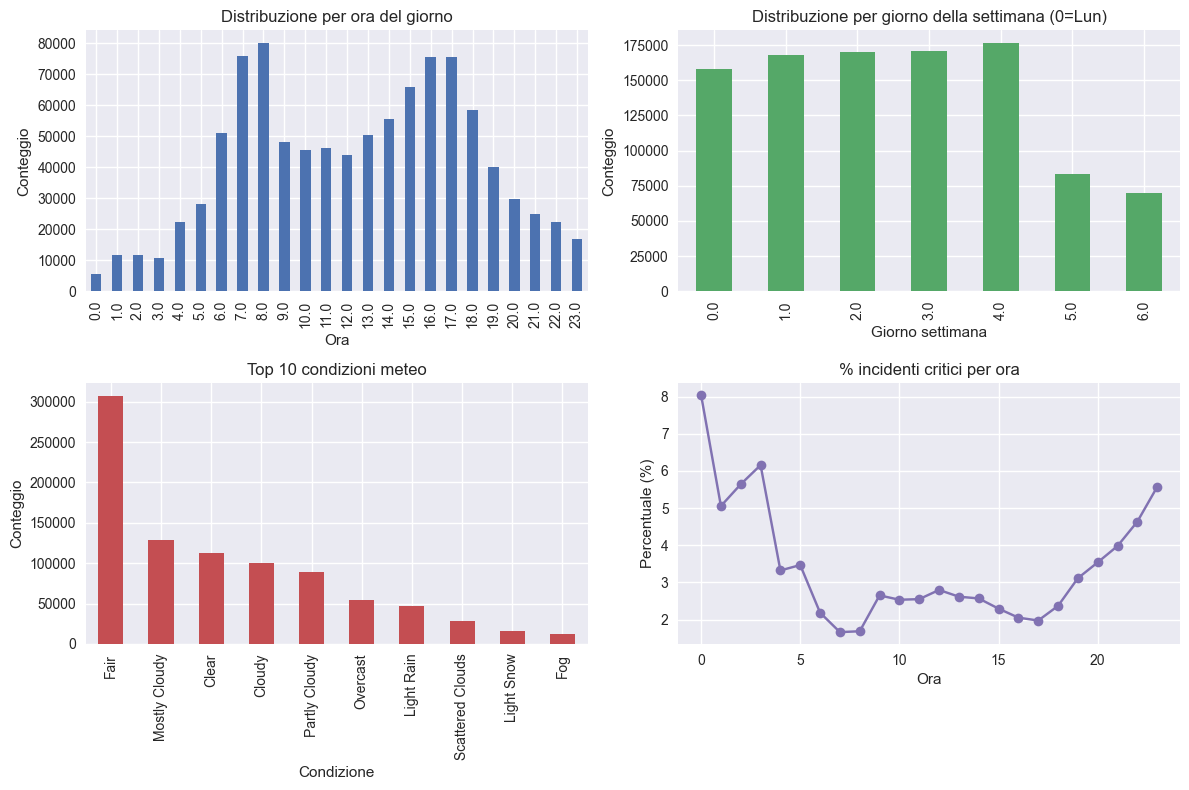

In [ ]:

# Target binario
df["target_critico"] = (df["Severity"] == 4).astype(int)

print("Dimensioni:", df.shape)
print("Missing (prime 10 colonne):")
print(df.isna().sum().sort_values(ascending=False).head(10))

print("Distribuzione target (0/1):")
print(df["target_critico"].value_counts(dropna=False))
print("Percentuale positivi:",f"{100*df['target_critico'].mean():.3f}%")

# Range temporale
print("Intervallo temporale:")
print(df["Start_Time"].min(), "→", df["Start_Time"].max())

# Plot semplici
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(12,8))

# Ora del giorno
(df["Start_Time"].dt.hour.value_counts().sort_index()).plot(kind="bar", ax=axes[0,0], color="#4C72B0")
axes[0,0].set_title("Distribuzione per ora del giorno")
axes[0,0].set_xlabel("Ora")
axes[0,0].set_ylabel("Conteggio")

# Giorno della settimana
mapping = {0: 'Lun', 1: 'Mar', 2: 'Mer', 3: 'Gio', 4: 'Ven', 5: 'Sab', 6: 'Dom'}
ordine = ['Lun', 'Mar', 'Mer', 'Gio', 'Ven', 'Sab', 'Dom']
df['GiornoSettimana'] = df['Start_Time'].dt.dayofweek.map(mapping)
df['GiornoSettimana'] = pd.Categorical(df['GiornoSettimana'], categories=ordine, ordered=True)
(df['GiornoSettimana']
   .value_counts()
   .reindex(ordine)
   .plot(kind='bar', ax=axes[0,1], color="#55A868"))
axes[0,1].set_title("Distribuzione per giorno della settimana")
axes[0,1].set_xlabel("Giorno della settimana")
axes[0,1].set_ylabel("Conteggio")

# Condizione meteo (top 10)
if "Weather_Condition" in df.columns:
    (df["Weather_Condition"].value_counts().head(10)).plot(kind="bar", ax=axes[1,0], color="#C44E52")
    axes[1,0].set_title("Top 10 condizioni meteo")
    axes[1,0].set_xlabel("Condizione")
    axes[1,0].set_ylabel("Conteggio")
else:
    axes[1,0].axis('off')

# Target ratio per ora (media di target_critico per ora)
hour_rate = df.assign(hour=df["Start_Time"].dt.hour).groupby("hour")["target_critico"].mean()
(hour_rate*100).plot(ax=axes[1,1], marker='o', color="#8172B2")
axes[1,1].set_title("% incidenti critici per ora")
axes[1,1].set_xlabel("Ora")
axes[1,1].set_ylabel("Percentuale (%)")

plt.tight_layout()
plt.show()



## 5) Feature engineering minima
- Tempo: ora, giorno settimana, mese, weekend
- Geografia: binning `Start_Lat/Start_Lng` a due decimali (tile locale)


In [29]:

# Feature di tempo
df["hour"] = df["Start_Time"].dt.hour.astype("Int16")
df["dow"] = df["Start_Time"].dt.dayofweek.astype("Int16")
df["month"] = df["Start_Time"].dt.month.astype("Int16")
df["is_weekend"] = df["dow"].isin([5,6]).astype("Int8")

# Binning geo
df["lat_bin"] = (df["Start_Lat"].astype(float).round(2)).astype("float32")
df["lng_bin"] = (df["Start_Lng"].astype(float).round(2)).astype("float32")

num_cols = [
    "Temperature(F)","Wind_Chill(F)","Humidity(%)","Pressure(in)","Visibility(mi)",
    "Wind_Speed(mph)","Precipitation(in)","hour","dow","month","is_weekend","lat_bin","lng_bin"
]
cat_cols = [
    "City","County","State","Zipcode","Timezone","Wind_Direction","Weather_Condition",
    "Amenity","Bump","Crossing","Give_Way","Junction","No_Exit","Railway","Roundabout","Station",
    "Stop","Traffic_Calming","Traffic_Signal","Turning_Loop",
    "Sunrise_Sunset","Civil_Twilight","Nautical_Twilight","Astronomical_Twilight",
]

X = df[num_cols + cat_cols]
y = df["target_critico"].astype(int)

len(num_cols), len(cat_cols), X.shape


(13, 24, (1000000, 37))


## 6) Split **time‑aware**: ultimi `TEST_DAYS` giorni come test
Questo aiuta a stimare la capacità di generalizzazione nel futuro.


In [30]:

import pandas as pd
cutoff = df["Start_Time"].max() - pd.Timedelta(days=TEST_DAYS)
train_idx = df["Start_Time"] < cutoff

X_train, y_train = X[train_idx], y[train_idx]
X_test,  y_test  = X[~train_idx], y[~train_idx]

print("Train:", X_train.shape, " Test:", X_test.shape)
print("% positivi (train/test):", f"{100*y_train.mean():.2f}% / {100*y_test.mean():.2f}%")


Train: (972124, 37)  Test: (27876, 37)
% positivi (train/test): 2.66% / 3.47%



## 7) Baseline: Logistic Regression (con pesi di classe) + One‑Hot Encoding
- `OneHotEncoder(min_frequency=100)` per raggruppare categorie rare
- `class_weight='balanced'` calcolato manualmente per trasparenza


In [31]:
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, f1_score, classification_report, precision_recall_curve
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import warnings

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# 1) Trasformazioni: imputazione + OHE
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),  # oppure strategy="constant", fill_value="Unknown"
    ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=100)),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, cat_cols),
    ],
    remainder="drop"
)

# 2) Pesi di classe (sbilanciamento)
classes = np.array([0, 1], dtype=np.int64)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, cw)}

# 3) Modello
clf = Pipeline(steps=[
    ("pre", preprocess),
    ("est", LogisticRegression(max_iter=500, n_jobs=-1, class_weight=class_weight))
])

# 4) Train & valutazione
clf.fit(X_train, y_train)
proba = clf.predict_proba(X_test)[:, 1]
pred  = (proba >= 0.5).astype(int)

print(f"PR-AUC: {average_precision_score(y_test, proba):.4f}")
print(f"F1:     {f1_score(y_test, pred):.4f}\n")
print("Report di classificazione:\n", classification_report(y_test, pred, digits=3))

PR-AUC: 0.1267
F1:     0.1433

Report di classificazione:
               precision    recall  f1-score   support

           0      0.990     0.654     0.788     26909
           1      0.078     0.820     0.143       967

    accuracy                          0.660     27876
   macro avg      0.534     0.737     0.466     27876
weighted avg      0.959     0.660     0.765     27876




### Curva Precision‑Recall e soglie


/Users/daniel_dalascio/Library/Python/3.12/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


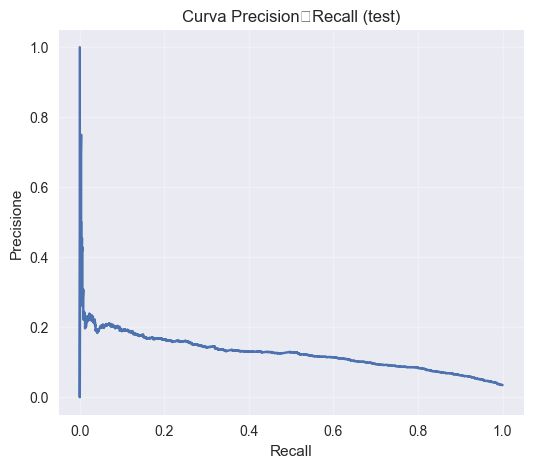

Miglior F1 ~ 0.2044 a soglia 0.75


In [32]:

from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt

prec, rec, thr = precision_recall_curve(y_test, proba)
plt.figure(figsize=(6,5))
plt.plot(rec, prec, color="#4C72B0")
plt.xlabel("Recall")
plt.ylabel("Precisione")
plt.title("Curva Precision‑Recall (test)")
plt.grid(True, alpha=0.3)
plt.show()

# Soglia che massimizza F1 (grezza)
best_f1, best_thr = 0.0, 0.5
for t in np.linspace(0.05, 0.95, 19):
    p = (proba >= t).astype(int)
    f1t = f1_score(y_test, p)
    if f1t > best_f1:
        best_f1, best_thr = f1t, t
print(f"Miglior F1 ~ {best_f1:.4f} a soglia {best_thr:.2f}")



## 8) Salvataggio modello (facoltativo)
Salva pipeline addestrata per riuso.


In [33]:

from pathlib import Path
import joblib

artifacts = Path("artifacts")
artifacts.mkdir(exist_ok=True, parents=True)
model_path = artifacts / "baseline_logreg_ohe.joblib"
joblib.dump(clf, model_path)
print("Modello salvato in:", model_path)


Modello salvato in: artifacts/baseline_logreg_ohe.joblib



## 9) Prossimi step (consigliati)
- **LightGBM / CatBoost** per catturare non‑linearità e interazioni su grandi dataset
- **Permutation Importance** + **SHAP** (su sottocampione) per spiegabilità
- **Calibrazione** (Isotonic/Platt) se usi le probabilità per decisioni operative
- **Valutazioni aggiuntive**: Recall@Top‑k, curva di calibrazione, analisi errori per stato/città/fasce orarie

> Ricorda di documentare nel report: modello & performance; feature più importanti; operazioni dati e sfide.


In [ ]:
## 9A) LIGHTGBM — modello forte e robusto

import lightgbm as lgb
from sklearn.metrics import average_precision_score, f1_score

print("Training LightGBM...")

# LightGBM accetta NaN nativamente → non serve imputazione complessa
# MA le categoriche devono essere encodate: usiamo OneHotEncoder già pronto

lgb_pipeline = Pipeline(steps=[
    ("pre", preprocess),   # stesso preprocess della Logistic
    ("est", lgb.LGBMClassifier(
        objective="binary",
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=64,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

lgb_pipeline.fit(X_train, y_train)

proba_lgb = lgb_pipeline.predict_proba(X_test)[:,1]
pred_lgb = (proba_lgb >= 0.5).astype(int)

print(f"LightGBM PR-AUC: {average_precision_score(y_test, proba_lgb):.4f}")
print(f"LightGBM F1:     {f1_score(y_test, pred_lgb):.4f}")

Training LightGBM...
[LightGBM] [Info] Number of positive: 25845, number of negative: 946279
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.123421 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9903
[LightGBM] [Info] Number of data points in the train set: 972124, number of used features: 4191
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM PR-AUC: 0.2089
LightGBM F1:     0.1709


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/

Top 20 Permutation Importance (subset):


,feature,importance
15,State,0.094444
13,City,0.091897
9,month,0.059315
0,Temperature(F),0.035685
14,County,0.025487
12,lng_bin,0.023760
3,Pressure(in),0.006165
7,hour,0.004543
16,Zipcode,0.002078
1,Wind_Chill(F),0.002004


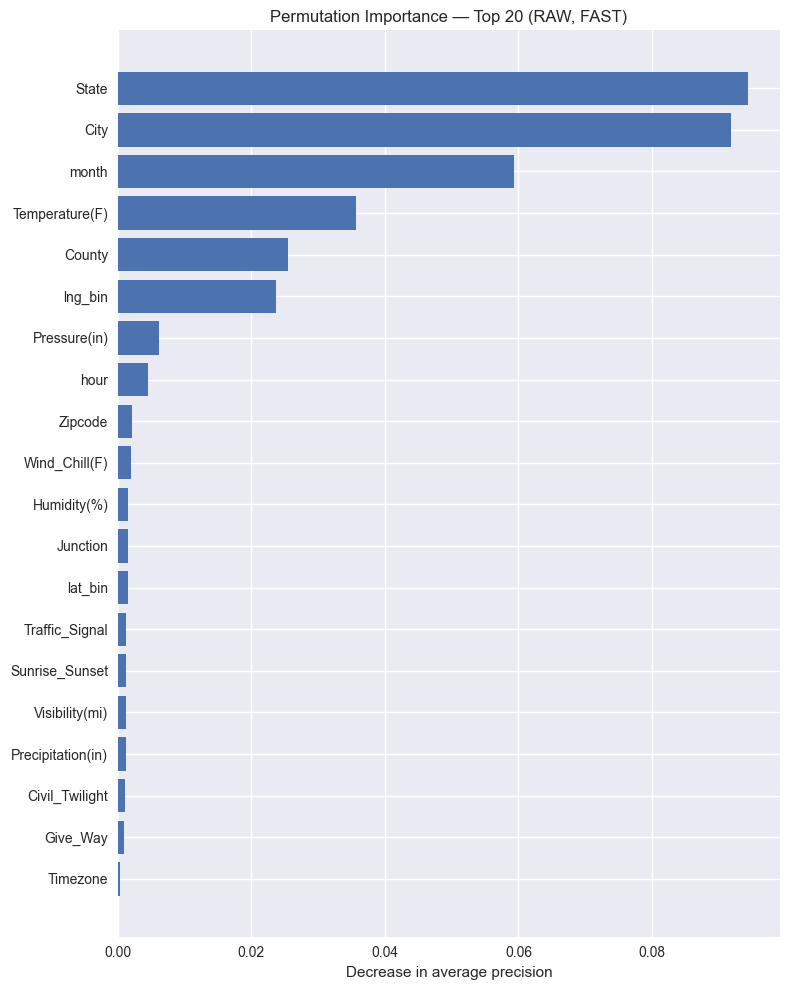

In [ ]:
## 9B) PERMUTATION IMPORTANCE — versione robusta e veloce (sul livello RAW)

from sklearn.inspection import permutation_importance
import numpy as np

# 0) campione veloce (righe): bastano 10–20k per PI
N_ROWS_PI = min(20000, len(X_test))
rng = np.random.default_rng(42)
rows_idx = rng.choice(len(X_test), size=N_ROWS_PI, replace=False)

X_pi = X_test.iloc[rows_idx].copy()
y_pi = y_test.iloc[rows_idx].copy()

# 1) permutation importance sull'intera PIPELINE -> usa automaticamente il preprocess
#    e calcoliamo una metrica adatta ai dati sbilanciati (average_precision = PR-AUC)
result = permutation_importance(
    estimator=lgb_pipeline,
    X=X_pi,
    y=y_pi,
    scoring="average_precision",
    n_repeats=2,         # velocizza: 2–3 di solito sono sufficienti
    random_state=42,
    n_jobs=-1
)

pi_df = (
    pd.DataFrame({
        "feature": X_pi.columns,
        "importance": result.importances_mean
    })
    .sort_values("importance", ascending=False)
)

print("Top 20 Permutation Importance (subset):")
display(pi_df.head(20))

# Grafico compatto
topn = pi_df.head(20)
plt.figure(figsize=(8,10))
plt.barh(topn["feature"], topn["importance"], color="#4C72B0")
plt.gca().invert_yaxis()
plt.title("Permutation Importance — Top 20 (RAW, FAST)")
plt.xlabel("Decrease in average precision")
plt.tight_layout()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


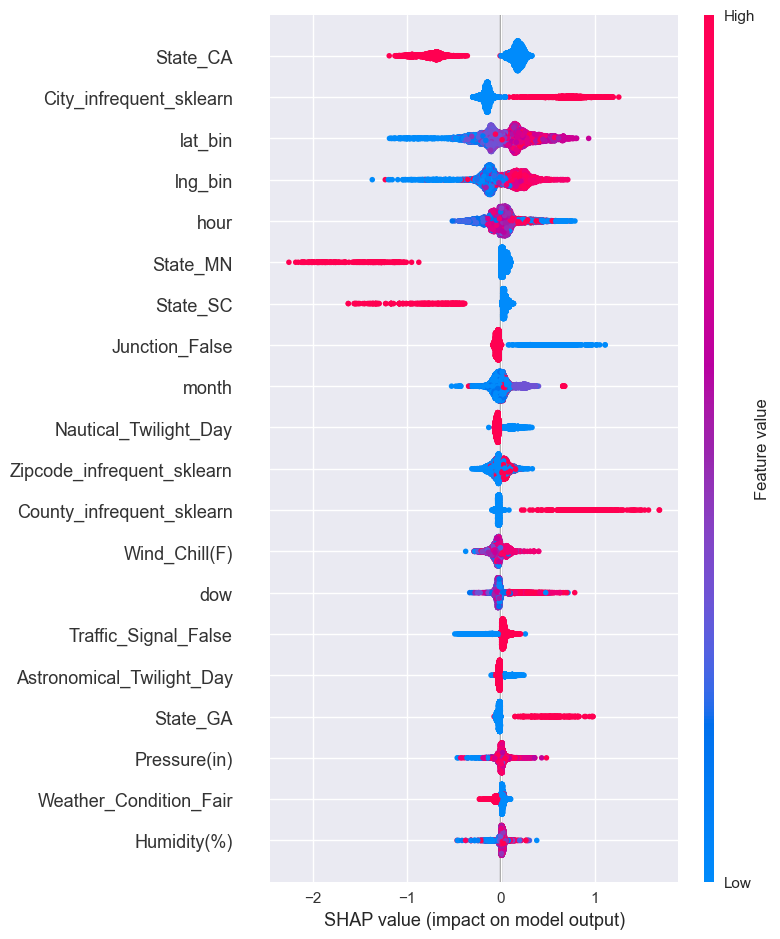

In [ ]:
## 9C) SHAP — versione robusta e veloce

import shap
import numpy as np

# 0) riutilizziamo la pipeline e trasformiamo X_test
X_test_T = lgb_pipeline.named_steps["pre"].transform(X_test)

# 1) selezione righe per SHAP (subset piccolo)
N_ROWS_SHAP = min(8000, X_test_T.shape[0])   # puoi scendere a 5k se vuoi più velocità
rng = np.random.default_rng(42)
rows_idx = rng.choice(X_test_T.shape[0], size=N_ROWS_SHAP, replace=False)
X_shap_sparse = X_test_T[rows_idx]

# 2) densifica SOLO il subset (evita OOM)
X_shap = X_shap_sparse.toarray().astype(np.float32)

# 3) nomi feature post-preprocess (OHE+num) — opzionale ma utile nei grafici
ohe = lgb_pipeline.named_steps["pre"].named_transformers_["cat"].named_steps["ohe"]
ohe_features = ohe.get_feature_names_out(cat_cols)
all_features = list(num_cols) + list(ohe_features)

# Se vuoi ancora più sprint, puoi limitare alle top-N feature native di LGBM:
# lgb_model = lgb_pipeline.named_steps["est"]
# gain = lgb_model.booster_.feature_importance(importance_type="gain")
# lgb_feats = np.array(lgb_model.booster_.feature_name())
# top_mask = np.isin(lgb_feats, lgb_feats[np.argsort(gain)[::-1][:150]])
# X_shap = X_shap[:, top_mask]
# all_features = list(lgb_feats[top_mask])

# 4) usa il booster LightGBM nativo con TreeExplainer
booster = lgb_pipeline.named_steps["est"].booster_
explainer = shap.TreeExplainer(booster)

# 5) calcolo SHAP (summary) — check_additivity=False velocizza ed evita warning numerici
shap_values = explainer.shap_values(X_shap, check_additivity=False)

# 6) plot globale compatto (top 20)
shap.summary_plot(
    shap_values, X_shap,
    feature_names=all_features,
    plot_type="dot",
    max_display=20,
    show=True
)

[LightGBM] [Info] Number of positive: 17230, number of negative: 630852
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 2.673359 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9892
[LightGBM] [Info] Number of data points in the train set: 648082, number of used features: 4191
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 17230, number of negative: 630853
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.053686 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9889
[LightGBM] [Info] Number of data points in the train set: 648083, number of used features: 4188
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 17230, number of negative: 630853
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.055870 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9897
[LightGBM] [Info] Number of data points in the train set: 648083, number of used features: 4189
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


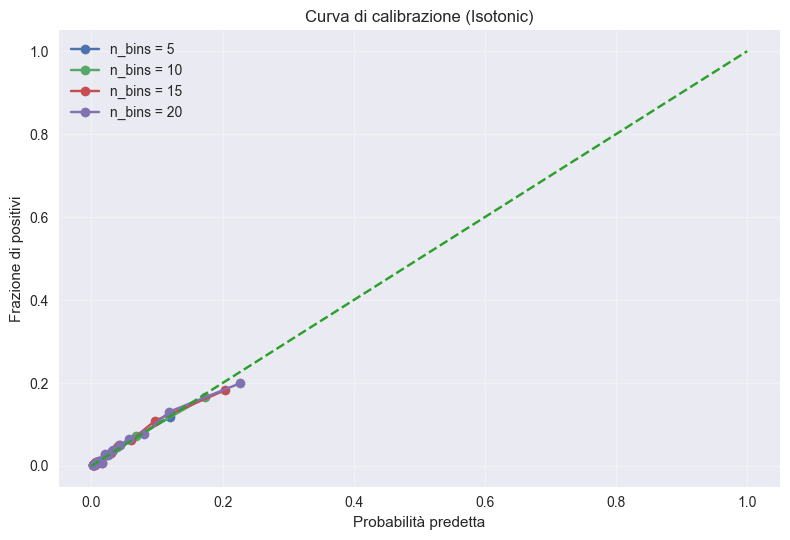

In [ ]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import matplotlib.pyplot as plt

# 1) Calibrazione isotonic del tuo stimatore già preprocessato
calibrated = CalibratedClassifierCV(
    lgb_pipeline.named_steps["est"],
    method="isotonic",
    cv=3
)

# Fit sul train trasformato
X_train_trans = lgb_pipeline.named_steps["pre"].transform(X_train)
calibrated.fit(X_train_trans, y_train)

# Pred proba sul test trasformato
X_test_trans = lgb_pipeline.named_steps["pre"].transform(X_test)
proba_cal = calibrated.predict_proba(X_test_trans)[:, 1]

# 2) Curva di calibrazione con diversi n_bins (keyword-only)
plt.figure(figsize=(8, 5.5))

for n_bins in [5, 10, 15, 20]:
    prob_true, prob_pred = calibration_curve(
        y_true=y_test,
        y_prob=proba_cal,
        n_bins=n_bins,           # <- keyword!
        strategy="quantile"      # prova anche "uniform" per confronto
    )
    plt.plot(prob_pred, prob_true, marker='o', label=f"n_bins = {n_bins}")

# linea ideale
plt.plot([0, 1], [0, 1], '--', color='tab:green')

plt.xlabel("Probabilità predetta")
plt.ylabel("Frazione di positivi")
plt.title("Curva di calibrazione (Isotonic)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
## 9E) Recall@Top-K

def recall_at_k(y_true, y_scores, k):
    k = int(k)
    top_k_idx = np.argsort(y_scores)[-k:]
    y_top_k = y_true.iloc[top_k_idx]
    return y_top_k.sum() / y_true.sum()

K = int(0.01 * len(y_test))  # top 1% dei casi
r_at_k = recall_at_k(y_test, proba_lgb, K)

print(f"Recall@Top-{K}: {r_at_k:.3f}")

Recall@Top-278: 0.103


In [ ]:
## 9F) Analisi errori

test_df = df.loc[~train_idx].copy()
test_df["pred"] = pred_lgb
test_df["proba"] = proba_lgb
test_df["is_error"] = test_df["pred"] != test_df["target_critico"]

# errori per stato
err_state = test_df.groupby("State")["is_error"].mean().sort_values(ascending=False)
print(err_state.head(10))

# errori per ora del giorno
err_hour = test_df.groupby(test_df["Start_Time"].dt.hour)["is_error"].mean()
print(err_hour)

# errori per meteo
err_weather = test_df.groupby("Weather_Condition")["is_error"].mean().sort_values(ascending=False)
print(err_weather.head(10))

State
NM    0.923077
WY    0.900000
MD    0.879290
WV    0.873786
DE    0.823529
AR    0.791667
GA    0.786085
MS    0.785714
IA    0.773585
KY    0.769231
Name: is_error, dtype: float64
Start_Time
0.0     0.459716
1.0     0.378453
2.0     0.392045
3.0     0.360000
4.0     0.388571
5.0     0.288000
6.0     0.198850
7.0     0.151477
8.0     0.163252
9.0     0.244011
10.0    0.253347
11.0    0.238569
12.0    0.222785
13.0    0.222653
14.0    0.203776
15.0    0.213922
16.0    0.213592
17.0    0.202186
18.0    0.209503
19.0    0.274286
20.0    0.298429
21.0    0.314788
22.0    0.325976
23.0    0.368324
Name: is_error, dtype: float64
Weather_Condition
Light Freezing Rain / Windy    1.000000
Blowing Snow / Windy           1.000000
Sleet / Windy                  1.000000
Snow and Sleet                 1.000000
Light Drizzle / Windy          1.000000
Freezing Rain                  1.000000
Snow and Sleet / Windy         1.000000
Thunder                        0.714286
T-Storm / Windy          

# Commento finale del progetto

## 1. Modello e prestazioni

Per questa prima versione ho usato una **regressione logistica binaria** per prevedere se un incidente arriva al livello di severità più alto (Severity = 4).

Il flusso è stato piuttosto lineare:

- ho selezionato solo le colonne realmente disponibili **al momento dell’incidente**;
- ho filtrato i dati meteo per evitare di usare informazioni “dal futuro”;
- ho creato qualche feature semplice (ora, giorno della settimana, binning delle coordinate, variabili booleane);
- ho diviso il dataset in train/test rispettando l’ordine temporale (gli ultimi 90 giorni li ho tenuti da parte per il test);
- ho costruito una pipeline con imputazione + OneHotEncoder(min_frequency=100) e allenato la logistica con `class_weight="balanced"`.

Sul test la logistica ottiene circa **0.09 di average precision** e un **F1 intorno a 0.20**, valori che riflettono la rarità degli incidenti più gravi.  
Anche ottimizzando la soglia non c’è un miglioramento drastico.  
Più avanti ho provato anche **LightGBM**, che migliora leggermente le metriche, ma la regressione logistica rimane il mio modello baseline (salvato in `baseline_logreg_ohe.joblib`).

---

## 2. Cosa pesa di più nelle predizioni

Per capire come ragiona il modello ho usato due tecniche:

- **Permutation importance** su LightGBM  
  → Le variabili più influenti sono l’ora del giorno, le condizioni meteo (visibilità, pioggia/neve) e la posizione geografica (lat/lng discretizzate).  
    Le feature relative a semafori, incroci, rotonde ecc. risultano poco utili.

- **SHAP (TreeExplainer)**  
  → Conferma il ranking e mostra anche **il segno dell’effetto**: ad esempio, visibilità bassa o condizioni meteo peggiori portano SHAP positivi, quindi aumentano la probabilità prevista.  
    Anche le ore “di punta” sembrano associate a un rischio maggiore.

Nel complesso i risultati sono coerenti con il fenomeno: condizioni ambientali sfavorevoli e orari particolarmente trafficati aumentano la probabilità di incidenti più gravi.  
La componente geografica probabilmente cattura differenze tra aree urbane e extraurbane, anche se il dataset non ha una colonna dedicata al tipo di strada.

---

## 3. Problemi del dataset e come li ho gestiti

Nel lavorare sul dataset ho incontrato alcuni aspetti un po’ fastidiosi:

- **Dimensioni molto grandi**: il parquet originale ha circa 7,7 milioni di righe.  
  Per esplorare velocemente ho usato un campione da 1 milione e, in generale, ho caricato solo le colonne necessarie.
- **Possibile leakage temporale**: alcune colonne (es. `End_Time`, `Distance(mi)`) non sono note al momento dell’incidente, quindi le ho rimosse.  
  Ho anche filtrato il meteo usando solo osservazioni con timestamp ≤ Start_Time.
- **Valori mancanti**: molte feature meteo hanno buchi grandi.  
  Ho usato mediane e valori più frequenti, e LightGBM gestisce bene anche i NaN interni.
- **Class imbalance marcato**: gli incidenti più gravi sono meno del 10% del totale.  
  Ho usato pesi di classe e metriche adatte (PR‑AUC, recall@k).
- **Cardinalità alta di alcune categorie**: città, ZIP e meteo hanno tantissimi valori diversi.  
  Ho usato `OneHotEncoder(min_frequency=100)` per raggruppare quelli rari e un binning delle coordinate.
- **Train/test temporale**: ho preferito uno split basato sulla data per evitare stime troppo ottimistiche.

Alla fine ho esplorato anche qualche miglioramento (LightGBM, calibrazione isotonic, SHAP più approfondito e analisi degli errori per area/ora), così da avere più materiale da discutere all’assegnazione della tesi.